In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Path.cwd()

PosixPath('/Users/rubinchang/delay-discounting-analysis/notebooks')

In [ ]:
file_path = Path("../data/raw/all_data.csv")

columns = pd.read_csv(file_path, nrows=0)
columns.columns.tolist()

['paper',
 'subj_idx',
 'subj_ident',
 'session',
 'sess_ident',
 'trial_idx',
 'ss_value',
 'ss_time',
 'll_value',
 'll_time',
 'choice',
 'rt',
 'subj_excl',
 'subj_excl_ind',
 'trial_excl',
 'trial_excl_ind',
 'age',
 'additional_conditions',
 'subset',
 'subset_label',
 'doi_publication',
 'link_data',
 'doi_data',
 'country',
 'currency',
 'time_unit',
 'procedure',
 'incentivization',
 'presentation_of_information',
 'additional_methods',
 'additional_interventions',
 'fixed_attributes',
 'time_pressure',
 'time_pressure_cont',
 'subj_excl_criteria',
 'trial_excl_criteria',
 'missing_trials_absolute',
 'missing_trials_relative',
 'online_study',
 'rt_in_full_seconds',
 'rt_data_analyzed',
 'comments']

In [3]:
sample = pd.read_csv(file_path, nrows=10)
sample

,paper,subj_idx,subj_ident,session,sess_ident,trial_idx,ss_value,ss_time,ll_value,ll_time,...,time_pressure,time_pressure_cont,subj_excl_criteria,trial_excl_criteria,missing_trials_absolute,missing_trials_relative,online_study,rt_in_full_seconds,rt_data_analyzed,comments
0,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,1,400000.0,1,404000.0,182.5,...,0,NaN,NaN,NaN,0,0,0,0,0,Subject number does not match paper; Some subj...
1,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,2,400000.0,1,408000.0,182.5,...,0,NaN,NaN,NaN,0,0,0,0,0,Subject number does not match paper; Some subj...
2,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,3,400000.0,1,420000.0,182.5,...,0,NaN,NaN,NaN,0,0,0,0,0,Subject number does not match paper; Some subj...
3,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,4,400000.0,1,440000.0,182.5,...,0,NaN,NaN,NaN,0,0,0,0,0,Subject number does not match paper; Some subj...
4,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,5,400000.0,1,500000.0,182.5,...,0,NaN,NaN,NaN,0,0,0,0,0,Subject number does not match paper; Some subj...
5,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,6,400000.0,1,560000.0,182.5,...,0,NaN,NaN,NaN,0,0,0,0,0,Subject number does not match paper; Some subj...
6,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,7,400000.0,1,680000.0,182.5,...,0,NaN,NaN,NaN,0,0,0,0,0,Subject number does not match paper; Some subj...
7,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,8,400000.0,1,800000.0,182.5,...,0,NaN,NaN,NaN,0,0,0,0,0,Subject number does not match paper; Some subj...
8,Alonso-Diaz_2022,G1S10,001_0002,1,001_0002_1,1,400000.0,1,404000.0,182.5,...,0,NaN,NaN,NaN,0,0,0,0,0,Subject number does not match paper; Some subj...
9,Alonso-Diaz_2022,G1S10,001_0002,1,001_0002_1,2,400000.0,1,408000.0,182.5,...,0,NaN,NaN,NaN,0,0,0,0,0,Subject number does not match paper; Some subj...


In [4]:
paper_names = set()

for chunk in pd.read_csv(
    file_path,
    usecols=["paper"],
    chunksize=100_000
):
    paper_names.update(chunk["paper"].dropna().unique())

paper_names = sorted(paper_names)

print("Number of studies:", len(paper_names))
paper_names[:20]

Number of studies: 100


['Alonso-Diaz_2022',
 'Alvarez_2022',
 'Amasino_2019',
 'Andersen_2014',
 'Armstrong_2024',
 'Bahrami_2023',
 'Becker_2023_Exp1',
 'Becker_2023_Exp2',
 'Becker_2023_Exp3',
 'Berenson_2016',
 'Bixter_2015_Exp1',
 'Bixter_2015_Exp2',
 'Bixter_2017',
 'Bixter_2019',
 'Bruder_2021',
 'Bulley_2022_Exp1',
 'Bulley_2022_Exp2',
 'Calluso_2015',
 'Calluso_2019',
 'Calluso_2020']

In [5]:
study_summaries = []

for paper in paper_names[:20]:
    parts = []

    for chunk in pd.read_csv(
        file_path,
        chunksize=100_000
    ):
        match = chunk[chunk["paper"] == paper]

        if not match.empty:
            parts.append(match)

    study = pd.concat(parts, ignore_index=True)

    study_summaries.append({
        "paper": paper,
        "trials": len(study),
        "participants": study["subj_ident"].nunique(),
        "currency": study["currency"].dropna().unique().tolist(),
        "ss_min": study["ss_value"].min(),
        "ss_max": study["ss_value"].max(),
        "ll_min": study["ll_value"].min(),
        "ll_max": study["ll_value"].max()
    })

study_summary_df = pd.DataFrame(study_summaries)
study_summary_df

/var/folders/74/phncxs7s4rjb0bn6wk8d_ddr0000gn/T/ipykernel_89281/4061422126.py:6: DtypeWarning: Columns (0: subj_idx, 1: link_data, 2: doi_data, 3: additional_methods, 4: additional_interventions, 5: subj_excl_criteria, 6: trial_excl_criteria) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/var/folders/74/phncxs7s4rjb0bn6wk8d_ddr0000gn/T/ipykernel_89281/4061422126.py:6: DtypeWarning: Columns (0: subset_label, 1: link_data, 2: doi_data, 3: additional_methods, 4: additional_interventions, 5: subj_excl_criteria, 6: trial_excl_criteria, 7: comments) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/var/folders/74/phncxs7s4rjb0bn6wk8d_ddr0000gn/T/ipykernel_89281/4061422126.py:6: DtypeWarning: Columns (0: subj_idx, 1: subset_label, 2: link_data, 3: doi_data, 4: additional_methods, 5: additional_interventions, 6: fixed_attributes, 7: subj_excl_criteria, 8: comments) have mixed types. Sp

,paper,trials,participants,currency,ss_min,ss_max,ll_min,ll_max
0,Alonso-Diaz_2022,2120,265,[COP],400000.000,400000.000,404000.0000,800000.0
1,Alvarez_2022,22116,21,[USD],0.200,1.500,0.7000,6.6
2,Amasino_2019,30474,217,[USD],0.500,10.000,10.0000,10.0
3,Andersen_2014,19539,501,[DKK],1500.000,3000.000,1503.0525,4500.0
4,Armstrong_2024,6006,76,[USD],15.625,984.375,1000.0000,1000.0
5,Bahrami_2023,4200,60,[Bahar Azadi Coin],0.000,39.000,40.0000,40.0
6,Becker_2023_Exp1,11188,174,[EUR],0.000,10.000,10.0000,10.0
7,Becker_2023_Exp2,12713,185,[EUR],0.000,10.000,10.0000,10.0
8,Becker_2023_Exp3,12469,182,[EUR],0.000,10.000,10.0000,10.0
9,Berenson_2016,1620,60,[USD],11.000,80.000,25.0000,85.0


In [7]:
selected_paper = "Becker_2023_Exp1"

study_parts = []

usecols = [
    "paper",
    "subj_ident",
    "trial_idx",
    "ss_value",
    "ss_time",
    "ll_value",
    "ll_time",
    "choice",
    "subj_excl",
    "trial_excl"
]

for chunk in pd.read_csv(
    file_path,
    usecols=usecols,
    chunksize=100_000
):
    match = chunk[chunk["paper"] == selected_paper]

    if not match.empty:
        study_parts.append(match)

study_df = pd.concat(study_parts, ignore_index=True)

study_df

,paper,subj_ident,trial_idx,ss_value,ss_time,ll_value,ll_time,choice,subj_excl,trial_excl
0,Becker_2023_Exp1,007_0001,1,1.5,0.0,10.0,180.0,1,False,False
1,Becker_2023_Exp1,007_0001,2,3.0,0.0,10.0,30.0,1,False,False
2,Becker_2023_Exp1,007_0001,3,5.5,0.0,10.0,180.0,0,False,False
3,Becker_2023_Exp1,007_0001,4,1.0,0.0,10.0,2.0,1,False,False
4,Becker_2023_Exp1,007_0001,5,1.5,0.0,10.0,0.0,0,False,False
...,...,...,...,...,...,...,...,...,...,...
11183,Becker_2023_Exp1,007_0174,74,7.5,0.0,10.0,30.0,1,False,False
11184,Becker_2023_Exp1,007_0174,75,2.5,0.0,10.0,180.0,1,False,False
11185,Becker_2023_Exp1,007_0174,76,0.5,0.0,10.0,0.0,0,False,False
11186,Becker_2023_Exp1,007_0174,77,1.5,0.0,10.0,0.0,0,False,False


In [8]:
print("Trials:", len(study_df))
print("Participants:", study_df["subj_ident"].nunique())

print("\nChoice counts:")
print(study_df["choice"].value_counts())

print("\nChoice proportions:")
print(study_df["choice"].value_counts(normalize=True))

print("\nSubject exclusions:")
print(study_df["subj_excl"].value_counts(dropna=False))

print("\nTrial exclusions:")
print(study_df["trial_excl"].value_counts(dropna=False))

Trials: 11188
Participants: 174

Choice counts:
choice
1    6873
0    4315
Name: count, dtype: int64

Choice proportions:
choice
1    0.614319
0    0.385681
Name: proportion, dtype: float64

Subject exclusions:
subj_excl
False    9898
True     1290
Name: count, dtype: int64

Trial exclusions:
trial_excl
False    11188
Name: count, dtype: int64


In [9]:
study_df[
    [
        "ss_value",
        "ss_time",
        "ll_value",
        "ll_time",
        "choice"
    ]
].describe()

,ss_value,ss_time,ll_value,ll_time,choice
count,11188.000000,11188.0,11188.0,11188.000000,11188.000000
mean,5.784412,0.0,10.0,125.783607,0.614319
std,3.012911,0.0,0.0,142.804408,0.486778
min,0.000000,0.0,10.0,0.000000,0.000000
25%,3.500000,0.0,10.0,2.000000,0.000000
50%,6.500000,0.0,10.0,30.000000,1.000000
75%,8.500000,0.0,10.0,180.000000,1.000000
max,10.000000,0.0,10.0,365.000000,1.000000


In [10]:
study_df[
    [
        "subj_ident",
        "ss_value",
        "ss_time",
        "ll_value",
        "ll_time",
        "choice"
    ]
].head(20)

,subj_ident,ss_value,ss_time,ll_value,ll_time,choice
0,007_0001,1.5,0.0,10.0,180.0,1
1,007_0001,3.0,0.0,10.0,30.0,1
2,007_0001,5.5,0.0,10.0,180.0,0
3,007_0001,1.0,0.0,10.0,2.0,1
4,007_0001,1.5,0.0,10.0,0.0,0
5,007_0001,4.5,0.0,10.0,2.0,1
6,007_0001,2.5,0.0,10.0,30.0,1
7,007_0001,3.0,0.0,10.0,365.0,0
8,007_0001,2.0,0.0,10.0,180.0,1
9,007_0001,6.0,0.0,10.0,0.0,0


In [11]:
clean_df = study_df[
    (~study_df["subj_excl"]) &
    (~study_df["trial_excl"])
].copy()

print("Clean trials:", len(clean_df))
print("Clean participants:", clean_df["subj_ident"].nunique())

Clean trials: 9898
Clean participants: 159


In [12]:
trials_per_participant = (
    clean_df.groupby("subj_ident")
    .size()
)

trials_per_participant.describe()

count    159.000000
mean      62.251572
std       17.762487
min       30.000000
25%       51.000000
50%       57.000000
75%       68.000000
max      134.000000
dtype: float64

In [13]:
participant_id = clean_df["subj_ident"].iloc[0]

participant_df = clean_df[
    clean_df["subj_ident"] == participant_id
].copy()

print("Participant:", participant_id)
print("Trials:", len(participant_df))

participant_df[
    ["ss_value", "ss_time", "ll_value", "ll_time", "choice"]
].head(10)

Participant: 007_0001
Trials: 76


,ss_value,ss_time,ll_value,ll_time,choice
0,1.5,0.0,10.0,180.0,1
1,3.0,0.0,10.0,30.0,1
2,5.5,0.0,10.0,180.0,0
3,1.0,0.0,10.0,2.0,1
4,1.5,0.0,10.0,0.0,0
5,4.5,0.0,10.0,2.0,1
6,2.5,0.0,10.0,30.0,1
7,3.0,0.0,10.0,365.0,0
8,2.0,0.0,10.0,180.0,1
9,6.0,0.0,10.0,0.0,0


In [16]:
beta = 0.5

def subjective_value(amount, delay, k):
    return amount / (1 + k * delay)


def ll_choice_probability(
    ss_value,
    ss_time,
    ll_value,
    ll_time,
    k,
    beta
):
    ss_subjective = subjective_value(
        ss_value,
        ss_time,
        k
    )

    ll_subjective = subjective_value(
        ll_value,
        ll_time,
        k
    )

    value_difference = ll_subjective - ss_subjective

    p_ll = 1 / (
        1 + np.exp(-beta * value_difference)
    )

    return p_ll

def real_log_likelihood(k, beta, participant_df):
    total = 0

    for _, row in participant_df.iterrows():
        p_ll = ll_choice_probability(
            row["ss_value"],
            row["ss_time"],
            row["ll_value"],
            row["ll_time"],
            k,
            beta
        )

        p_ll = np.clip(
            p_ll,
            1e-10,
            1 - 1e-10
        )

        if row["choice"] == 1:
            total += np.log(p_ll)
        else:
            total += np.log(1 - p_ll)

    return total

In [19]:
candidate_ks = np.linspace(0.0001, 0.2, 300)

log_likelihoods = []

for candidate_k in candidate_ks:
    ll = real_log_likelihood(
        candidate_k,
        beta,
        participant_df
    )

    log_likelihoods.append(ll)

best_index = np.argmax(log_likelihoods)
estimated_k = candidate_ks[best_index]

print("Estimated k:", estimated_k)

Estimated k: 0.006785618729096991


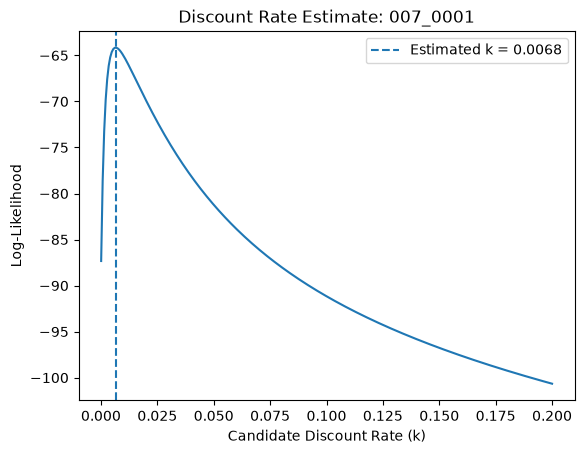

In [21]:
plt.plot(candidate_ks, log_likelihoods)

plt.axvline(
    estimated_k,
    linestyle="--",
    label=f"Estimated k = {estimated_k:.4f}"
)

plt.xlabel("Candidate Discount Rate (k)")
plt.ylabel("Log-Likelihood")
plt.title(f"Discount Rate Estimate: {participant_id}")
plt.legend()

plt.show()

Initial real-data fit: With choice sensitivity fixed at β = 0.5, participant 007_0001 had a maximum-likelihood discount-rate estimate of approximately k = 0.0068. The likelihood curve shows a clear maximum within the tested range, indicating that the participant’s choices contain information about their discount rate. Because β was fixed arbitrarily, this estimate should be treated as a preliminary model check rather than a final participant-level estimate.

In [ ]:
candidate_ks = np.logspace(
    np.log10(0.0001),
    np.log10(0.2),
    150
)

candidate_betas = np.linspace(
    0.005,
    3,
    150
)

likelihood_grid = np.empty(
    (len(candidate_betas), len(candidate_ks))
)

def fit_participant(participant_df, candidate_ks, candidate_betas):
    best_ll = -np.inf
    best_k = None
    best_beta = None

    for beta in candidate_betas:
        for k in candidate_ks:
            ll = real_log_likelihood_vectorized(
                k,
                beta,
                participant_df
            )

            if ll > best_ll:
                best_ll = ll
                best_k = k
                best_beta = beta

    return best_k, best_beta, best_ll

Estimated k: 0.0035548351111569653
Estimated beta: 0.10550335570469799
Maximum log-likelihood: -51.18840424604966


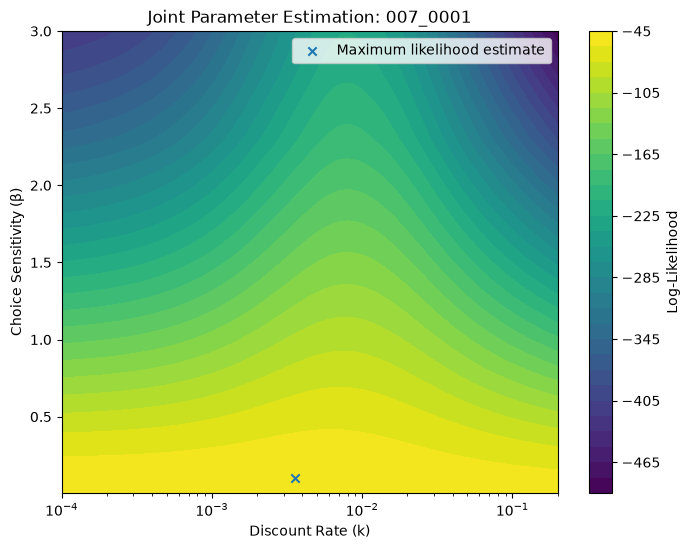

In [29]:
plt.figure(figsize=(8, 6))

contour = plt.contourf(
    candidate_ks,
    candidate_betas,
    likelihood_grid,
    levels=30
)

plt.xscale("log")

plt.scatter(
    best_k,
    best_beta,
    marker="x",
    label="Maximum likelihood estimate"
)

plt.xlabel("Discount Rate (k)")
plt.ylabel("Choice Sensitivity (β)")
plt.title(f"Joint Parameter Estimation: {participant_id}")

plt.colorbar(contour, label="Log-Likelihood")

plt.legend()
plt.show()

Joint parameter fit: Allowing both parameters to vary produced maximum-likelihood estimates of approximately k = 0.0037 and beta = 0.11 for participant 007_0001. The estimate of k differs from the earlier fixed-beta estimate, demonstrating that assumptions about choice sensitivity affect inferred discount rates. The likelihood surface also allows us to inspect whether combinations of k and beta are uniquely identifiable from the participant's choices.

In [26]:
def real_log_likelihood_vectorized(k, beta, participant_df):
    ss_value = participant_df["ss_value"].to_numpy()
    ss_time = participant_df["ss_time"].to_numpy()
    ll_value = participant_df["ll_value"].to_numpy()
    ll_time = participant_df["ll_time"].to_numpy()
    choices = participant_df["choice"].to_numpy()

    ss_subjective = ss_value / (1 + k * ss_time)
    ll_subjective = ll_value / (1 + k * ll_time)

    value_difference = ll_subjective - ss_subjective

    p_ll = 1 / (
        1 + np.exp(-beta * value_difference)
    )

    p_ll = np.clip(
        p_ll,
        1e-10,
        1 - 1e-10
    )

    choice_probabilities = np.where(
        choices == 1,
        p_ll,
        1 - p_ll
    )

    return np.log(choice_probabilities).sum()